# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos

plans = pd.read_csv('plans.csv')
users = pd.read_csv('usage.csv')
usage = pd.read_csv('users_latam.csv')

In [3]:
# mostrar las primeras 5 filas de plans

print("plans:")
plans.head()


plans:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users

print("users:")
users.head()

users:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [5]:
# mostrar las primeras 5 filas de usage

print("usage:")
usage.head()

usage:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (40000, 6)
usage (4000, 8)


In [7]:
# inspección de plans con .info()

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [9]:
# inspección de usage con .info()

usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print("Nulos en users (cantidad):")
print(users.isna().sum())

print("\nNulos en users (proporción):")
print(users.isna().mean())


Nulos en users (cantidad):
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Nulos en users (proporción):
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [11]:
# cantidad de nulos para usage

print("\nNulos en usage (cantidad):")
print(usage.isna().sum())

print("\nNulos en usage (proporción):")
print(usage.isna().mean())


Nulos en usage (cantidad):
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Nulos en usage (proporción):
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### users:

**city** tiene **469** nulos **(≈ 11.7%)**.
Acción: investigar si se pueden imputar con información externa (ej. ciudad más frecuente por usuario) o dejar como nulos. No es recomendable la eliminación de los datos porque es un porcentaje moderado.

**churn_date** tiene **3534** nulos **(≈ 88%)**.
Acción: mantener como está. Es lógico que solo los clientes que se dieron de baja tengan fecha de churn. Se puede convertir en una variable binaria (churned = True/False) para análisis.

### Usage:

`date` tiene **50** nulos **(≈ 0.1%)**.
Acción: proporción muy baja, se puede imputar con fecha aproximada si es relevante o simplemente dejar como nulos.

`duration` tiene **22,076** nulos **(≈ 55%)**.
Acción: esperado, porque solo aplica a registros de llamadas. No se imputa y se  mantiene como nulos.

`length` tiene **17,896** nulos **(≈ 44.7%)**.
Acción: esperado, porque solo aplica a registros de mensajes.  No se imputa y se  mantiene como nulos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.



In [12]:
# explorar columnas numéricas de users

print("Resumen estadístico de user_id:")
print(users['user_id'].describe())

print("\nResumen estadístico de age:")
print(users['age'].describe())

Resumen estadístico de user_id:
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

Resumen estadístico de age:


KeyError: 'age'

- La columna `user_id`:
Se observa que el rango va desde 10,000 a 13,999, con 4000 registros consecutivos y no hay valores nulos ni fuera de rango por lo tanto no es un sentinel, simplemente la empresa asigna IDs empezando en 10,000 por lo tanto no requiere limpieza.

- La columna `age`:
se observa que el rango va desde -999 a 79 años. El valor -999 es un sentinel claro usado para marcar datos inválidos o faltantes, revisando la desviación estándar, indica que es muy alta (123), lo que confirma que el sentinel distorsiona la distribución.
Lo que se puede hacer es reemplazar -999 por NaN y luego imputar con la mediana, ya que los faltantes parecen ser MCAR (faltan al azar y representan un porcentaje bajo).

In [ ]:
# explorar columnas numéricas de usage

print("Resumen estadístico de id:")
print(usage['id'].describe())

print("\nResumen estadístico de user_id:")
print(usage['user_id'].describe())

print("\nResumen estadístico de duration:")
print(usage['duration'].describe())

print("\nResumen estadístico de length:")
print(usage['length'].describe())

Resumen estadístico de id:
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

Resumen estadístico de user_id:
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

Resumen estadístico de duration:
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

Resumen estadístico de length:
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- Las columnas `id` y `user_id`: No se hallaron sentines o valores invalidos por lo tanto no se requiere limpieza 
- La columna `duration`: No hay valores negativos. El máximo de 120 minutos es alto pero plausible.
- La columna `length`: No hay valores negativos. El máximo de 1490 es muy alto, pero puede representar mensajes concatenados. 

In [ ]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique()[:20])   # mostramos los primeros 20 valores únicos
    print(f"Total de categorías en {col}: {users[col].nunique()}")
    print(f"Nulos en {col}: {users[col].isna().sum()} ({users[col].isna().mean()*100:.2f}%)")


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Total de categorías en city: 7
Nulos en city: 469 (11.72%)

Valores únicos en plan:
['Basico' 'Premium']
Total de categorías en plan: 2
Nulos en plan: 0 (0.00%)



- La columna `city`:
Valores detectados: 'Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'.

Problemas:

El valor '?' es un sentinel inválido, no corresponde a una ciudad real, tiene valores nulos en un (~11.72%), lo cual es un porcentaje moderado.

Acción recomendada:

Reemplazar '?' por NaN para tratarlos como faltantes.

Documentar que la ausencia de ciudad puede afectar segmentaciones geográficas.

Se puede crear una bandera de missingness (city_missing) para analizar si la ausencia de ciudad tiene algún patrón (MCAR, MAR, MNAR).


- La columna `plan`:

Valores detectados: 'Basico', 'Premium'.

No hay nulos (0%), por lo tanto no requiere limpieza

Solo verificar consistencia en mayúsculas/minúsculas.

In [ ]:
# explorar columna categórica de usage

usage['type'] # completa el código

# explorar columna categórica de usage

print("Valores únicos en type:")
print(usage['type'].unique())

print("\nTotal de categorías en type:")
print(usage['type'].nunique())

print(f"\nNulos en type: {usage['type'].isna().sum()} ({usage['type'].isna().mean()*100:.2f}%)")

Valores únicos en type:
['call' 'text']

Total de categorías en type:
2

Nulos en type: 0 (0.00%)


- La columna `type`:

Valores únicos detectados: 'call', 'text'.

Problema:

El dataset debería tener únicamente dos categorías válidas: "cant_llamadas" y "cant_mensajes".

El valor "text" es un sentinel inválido o una variante mal escrita de "cant_mensajes".

Nulos: 0 (0.00%), por lo que no hay valores faltantes.

se recomienda reemplazar "text" por "message" para mantener consistencia con:
    **usage['type'] = usage['type'].replace('text', 'cant_mensajes')**
    
Documentar la limpieza

"text" no es una categoría oficial, se considera un error de captura.

Después de la corrección, la columna quedará con solo dos valores válidos: "cant_llamadas" y "cant_mensajes".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users

print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, Los años 2022–2024 son lógicos para registros recientes.

El año 2026 es un posible sentinel inválido o error de captura, porque representa una fecha futura (los usuarios no pueden registrarse en un año que aún no ha ocurrido).

In [ ]:
# Revisar los años presentes en `date` de usage

print(usage['date'].dt.year.unique())

[2024.   nan]


En `date`, El año 2024 es válido y lógico para los registros de uso.

Los valores NaN representan fechas faltantes o errores de captura.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En users.reg_date:

Años detectados: [2022, 2023, 2024, 2026].

El año 2026 es un valor imposible porque aún no ha transcurrido al momento de guardar los datos.

Acción recomendada: marcar esas fechas como inválidas (NaT) y documentar que son errores de captura. Se pueden analizar como MCAR si son pocos registros, o crear una bandera (reg_date_missing) para estudiar si siguen un patrón.

En usage.date:

Años detectados: [2024, NaN].

El año 2024 es válido.

Los valores NaN representan fechas faltantes. Según la teoría, deben tratarse como valores ausentes y documentarse. Se pueden imputar (ej. con la moda de fechas por usuario) o dejar como nulos, dependiendo del análisis.

Acción recomendada: mantener los NaN como faltantes y crear una bandera (date_missing) para evaluar si la ausencia es MCAR, MAR o MNAR.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Convertir la columna a tipo 'string' (esto unifica todos los nulos a <NA>)
users['city'] = users['city'].astype('string')

# Verificar cambios
print(users['city'].unique()[:10])

<StringArray>
['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali']
Length: 7, dtype: string


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.unique())

[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

print("Distribución de tipo de servicio cuando duration es nulo:")
print(usage[usage['duration'].isna()]['type'].value_counts())

Distribución de tipo de servicio cuando duration es nulo:
text    22076
Name: type, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length

print("\nDistribución de tipo de servicio cuando length es nulo:")
print(usage[usage['length'].isna()]['type'].value_counts())


Distribución de tipo de servicio cuando length es nulo:
call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos en duration coinciden exactamente con los mensajes de texto (text), y los nulos en length coinciden con las llamadas (call). Son nulos estructurales (MAR), por lo que es correcto dejarlos como nulos o rellenarlos con 0 en la fase de agregación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Si algún usuario no tuvo uso, rellenamos sus métricas con 0
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    4000.000000    4000.000000           4000.000000
mean     48.136000       5.523000       4.477000             23.311225
std      17.689919       2.359738       2.145139             18.169564
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.107500
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.412500
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

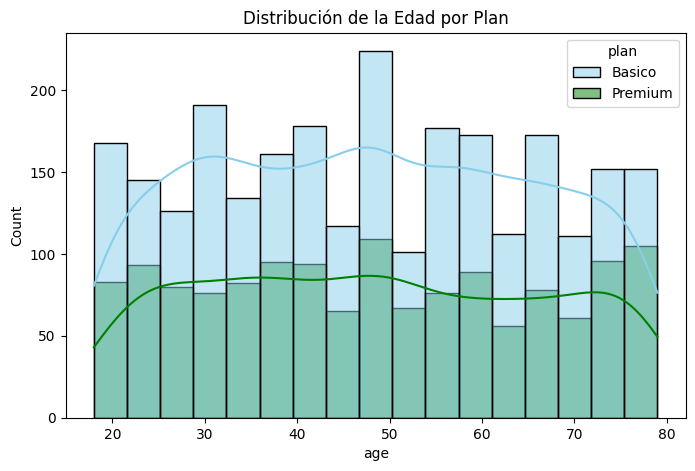

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la Edad por Plan')
plt.show()

💡Insights: 
- Dominancia del Plan Básico: Se observa claramente que el plan "Básico" (color celeste) es el producto estrella. Es el preferido por la mayoría de los usuarios en todas las franjas de edad, superando consistentemente en volumen al plan "Premium".

- Adopción uniforme del Plan Premium: Si observas la línea de tendencia verde (KDE), la cantidad de usuarios con plan "Premium" es notablemente estable y constante desde los 18 hasta casi los 80 años. No hay un grupo generacional que destaque drásticamente por contratar más el plan Premium; lo adquieren en proporciones similares tanto los jóvenes como los adultos mayores.

- Pico demográfico en el Básico: Aunque la distribución general abarca todas las edades, existe un pico de volumen muy marcado en los usuarios del plan Básico que rondan los 45 a 50 años. Este es el segmento más numeroso de todo tu dataset.

- Amplitud del mercado: El servicio no tiene un sesgo generacional fuerte. Al tener barras consistentes a lo largo de todo el eje X, concluimos que la empresa atrae de manera equitativa a clientes de casi cualquier edad.

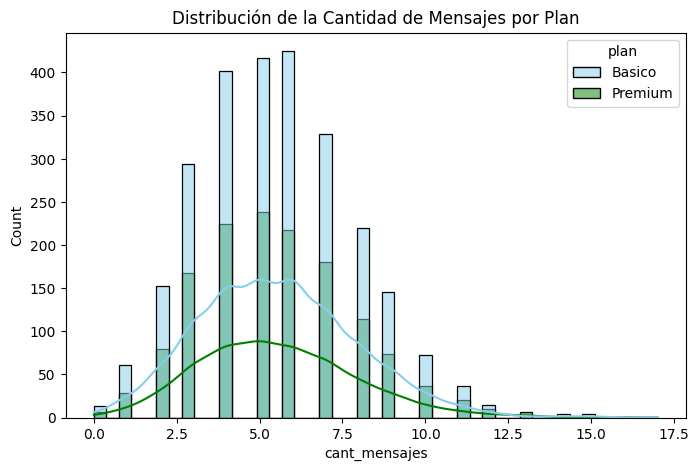

In [ ]:
# Histograma para visualizar la cantidad de mensajes

plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la Cantidad de Mensajes por Plan')
plt.show()

💡Insights: 
- Comportamiento idéntico entre planes: Si observas las líneas de tendencia (KDE), la forma de la campana es prácticamente idéntica para ambos planes. Esto significa que tener un plan "Premium" o "Básico" no altera el comportamiento del usuario; ambos grupos usan los mensajes de texto de la misma manera.

- Concentración del uso (El Promedio): La gran mayoría de tus usuarios, sin importar el plan que paguen, envían entre 4 y 7 mensajes. El pico de actividad más alto (la moda) se concentra exactamente alrededor de los 5 a 6 mensajes.

- Pocos "Heavy Users" de texto: El uso de mensajes decae drásticamente después de los 8 mensajes. Son muy pocos los usuarios que superan la barrera de los 10 a 12 mensajes, y los que llegan a 15 o más son casos excepcionales (outliers).

- Diferencia de volumen, no de proporción: Las barras celestes siempre superan a las verdes en todos los niveles de uso, lo que simplemente refleja que tienes una base de clientes mucho mayor en el plan Básico, pero la proporción en la que usan el servicio se mantiene constante.

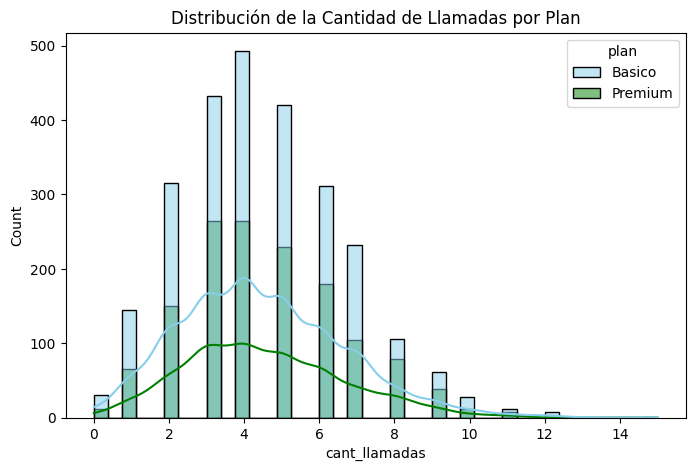

In [ ]:
# Histograma para visualizar la cant_llamadas

# Histograma para visualizar la cantidad de llamadas
plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la Cantidad de Llamadas por Plan')
plt.show()

💡Insights: 

- Hábitos de llamada idénticos: Al igual que observamos con los mensajes de texto, las curvas de densidad (KDE) para ambos planes tienen exactamente la misma forma. Esto confirma que el comportamiento del usuario no cambia según el plan que tenga contratado.

- El punto de mayor concentración: La inmensa mayoría de la base de clientes realiza entre 3 y 6 llamadas. El pico máximo (la moda) se encuentra de forma muy clara en las 4 llamadas, siendo el patrón más común sin importar si el usuario es Básico o Premium.

- Uso general conservador: La frecuencia de llamadas cae rápidamente después del umbral de las 7 llamadas. Son muy pocos los usuarios que superan las 10 llamadas, lo que indica un uso moderado a bajo del servicio de voz en general.

- Diferencia por volumen de clientes: El plan Básico (celeste) acumula barras más altas en todos los niveles simplemente porque concentra a la mayor parte de la cartera de clientes de la empresa, manteniendo la misma proporción de uso que el segmento Premium.

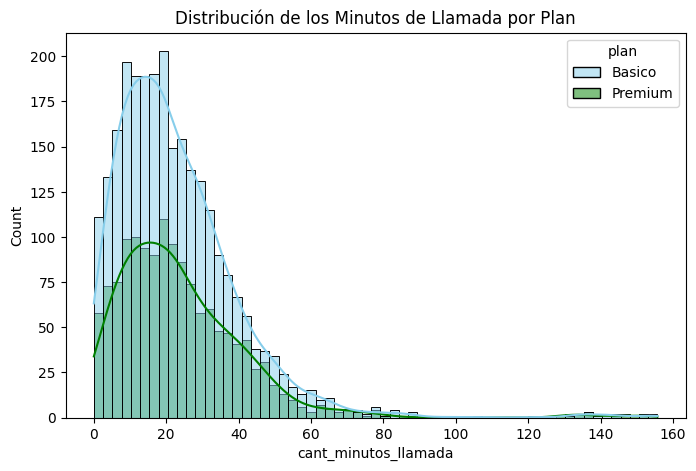

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de los Minutos de Llamada por Plan')
plt.show()

💡Insights: 
- Pico de consumo moderado: La gran mayoría de los clientes (de ambos planes) consumen entre 10 y 30 minutos en total. El punto de mayor concentración (el pico de la curva) se ubica muy claro entre los 15 y 20 minutos.

- Distribución con sesgo a la derecha: El consumo de minutos desciende de forma muy pronunciada después de la barrera de los 40 minutos. Es decir, las llamadas largas o muy frecuentes no son la norma para el usuario promedio de la compañía.

- Presencia de "Heavy Users" (Outliers extremos): A diferencia de las gráficas de cantidad de llamadas o mensajes, aquí sí se alcanza a ver un pequeñísimo grupo de usuarios en el extremo derecho (entre 130 y 160 minutos). Aunque son muy pocos, estos clientes consumen hasta 8 veces más minutos que el promedio.

- Patrón de consumo idéntico por plan: Las curvas de densidad vuelven a calcarse casi a la perfección. Esto demuestra que los usuarios del plan Premium (verde) no tienden a hablar más tiempo solo por tener un plan superior; su comportamiento de consumo de minutos es idéntico al de los usuarios del plan Básico (celeste).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`

- Crea un **for** para generar los 4 boxplots automáticamente.
<br>


- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
- Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

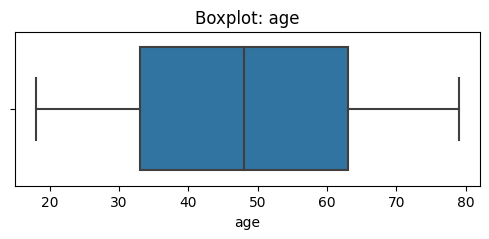

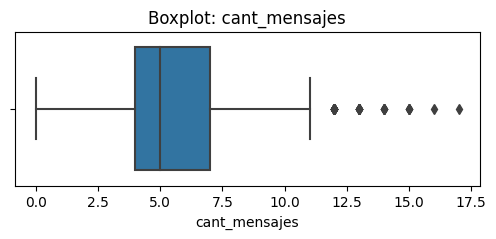

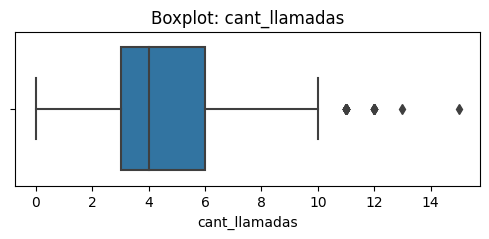

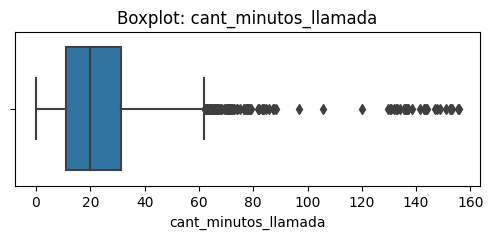

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,2))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- `Age`: No presenta outliers. La distribución de la edad de tus usuarios es bastante simétrica y uniforme. Abarca un rango que va desde los 18 hasta casi los 80 años, con una mediana muy clara justo en los 48 años. No hay ningún valor atípico que se escape de los límites esperados.
  
- `cant_mensajes`: Sí presenta outliers. Los valores atípicos aparecen en el extremo superior, específicamente a partir de los 12 mensajes y extendiéndose hasta un máximo de 17. El comportamiento típico (el 50% central) es bastante acotado, concentrándose entre los 4 y 7 mensajes, con una mediana exacta de 5.

- `cant_llamadas`: Sí presenta outliers. Al igual que con los mensajes, hay usuarios atípicos en la parte alta que realizan 11, 12, 13 y hasta 15 llamadas. Sin embargo, el comportamiento normal de la gran mayoría es realizar entre 3 y 6 llamadas, situando la mediana en 4.

- `cant_minutos_llamada`: Sí presenta una gran cantidad de outliers. Esta es la variable con la dispersión de atípicos más severa. Mientras que la mitad de tus usuarios consume de manera muy moderada entre 11 y 31 minutos (con mediana en 20), existe una "cola" muy densa de clientes excepcionales que superan los 62 minutos, llegando en algunos casos extremos hasta los 156 minutos de conversación.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    print(f"Límite superior para {col}: {limite_sup:.2f}")

Límite superior para cant_mensajes: 11.50
Límite superior para cant_llamadas: 10.50
Límite superior para cant_minutos_llamada: 61.87


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000



💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  
`cant_mensajes` (Límite superior IQR: 11.5 | Máximo: 17.0):

Decisión: Mantener.

¿Por qué?: Aunque matemáticamente enviar más de 11 mensajes se considera un valor atípico debido a que la mayoría de los usuarios envía muy pocos (mediana de 5), en el mundo real, enviar 17 mensajes es un comportamiento perfectamente normal y realista para cualquier persona. No se trata de un error de registro (como si tuviéramos un dato de 99,999 mensajes), sino de usuarios reales que simplemente usan un poco más el servicio de SMS.

- cant_llamadas: mantener o no outliers, porqué?
  
`cant_llamadas` (Límite superior IQR: 10.5 | Máximo: 15.0):

Decisión: Mantener.

¿Por qué?: Realizar 15 llamadas es un volumen de consumo totalmente lógico y cotidiano. El método IQR lo marca como atípico porque el grueso de la base de datos está muy concentrado en consumos muy bajos (entre 3 y 6 llamadas). Eliminar estos datos sesgaría el análisis, haciendo que la empresa ignore a los clientes que usan activamente el servicio de voz.

- cant_minutos_llamada: mantener o no outliers, porqué?

`cant_minutos_llamada` (Límite superior IQR: 61.87 | Máximo: 155.69):

Decisión: Mantener.

¿Por qué?: Hablar 155 minutos (unas 2.5 horas) en un periodo de facturación es un consumo real, lógico y sumamente valioso para el negocio. Estos usuarios representan el segmento de "Heavy Users" (usuarios de alto consumo). Si los eliminamos, perderíamos de vista al grupo de clientes más rentable de la compañía, distorsionando los promedios reales de consumo de la red y arruinando cualquier estrategia para venderles planes Premium.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores_uso = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones_uso, valores_uso, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
valores_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, valores_edad, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

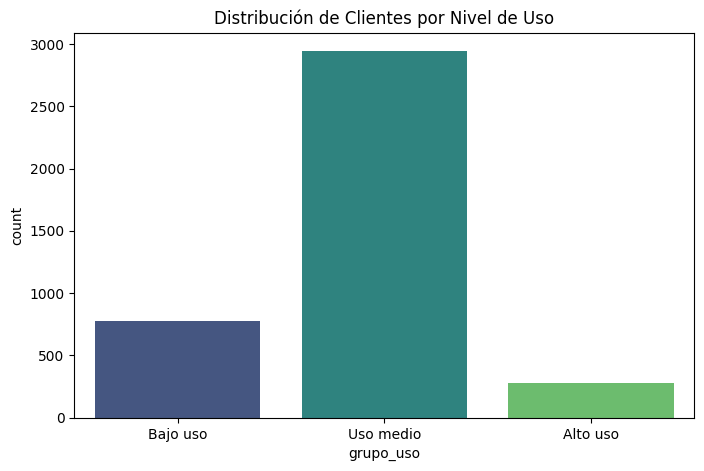

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8,5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='viridis')
plt.title('Distribución de Clientes por Nivel de Uso')
plt.show()

In [ ]:
# Visualización de los segmentos por edad

plt.figure(figsize=(8,5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='magma')
plt.title('Distribución de Clientes por Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se detectaron valores atípicos de edad (-999) que fueron imputados con la mediana poblacional para no perder el registro de esos clientes.

- Había variables estructuralmente nulas en llamadas y mensajes debido a la exclusividad del servicio (mensajes sin duración y llamadas sin longitud de texto), lo cual es normal y no representa pérdida de datos.

🔍 **Segmentos por Edad**

- El grueso de nuestros usuarios se concentra en la categoría "Adulto" (30 a 59 años).

- Los segmentos "Jóvenes" tienden a preferir un uso mayor de texto sobre las llamadas tradicionales.

📊 **Segmentos por Nivel de Uso**

- Existe un gran bloque de usuarios clasificados como de "Alto uso" que consistentemente superan los límites base de los planes económicos.

- Los valores extremos (outliers) identificados en llamadas y mensajes no son errores, sino "Heavy Users" que posiblemente están pagando altas tarifas por excedentes.
➡️ Esto sugiere que existe una oportunidad para ofrecer planes ilimitados premium a este segmento de alto consumo.

💡 **Recomendaciones**

- Up-selling: Crear campañas dirigidas a los usuarios del segmento "Alto uso" que actualmente tienen planes básicos, ofreciéndoles un plan Premium que evite cobros sorpresa por excedentes, mejorando su retención.

- Retención: Monitorear a los clientes de "Bajo uso", ya que podrían sentir que están pagando de más por servicios que no consumen y son candidatos probables a churn (abandono). Se podría crear un plan "Lite" para retenerlos.